## Step 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2. Load Dataset.

In [3]:
df = pd.read_csv("loan_approval_dataset.csv")

## Step 3. Understand Dataset

In [4]:
df.head()

df.shape

df.columns

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Step 4. Data Cleaning

In [5]:
## remove extra spaces
df.columns = df.columns.str.strip()

In [6]:
## missing values
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [7]:
## duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
## remove unnecessary columns
df.drop("loan_id", axis=1, inplace=True)

## Step 5. Exploratory data analysis

### Loan status count

C:\Users\saini\AppData\Local\Temp\ipykernel_16208\3862807728.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='Set2')


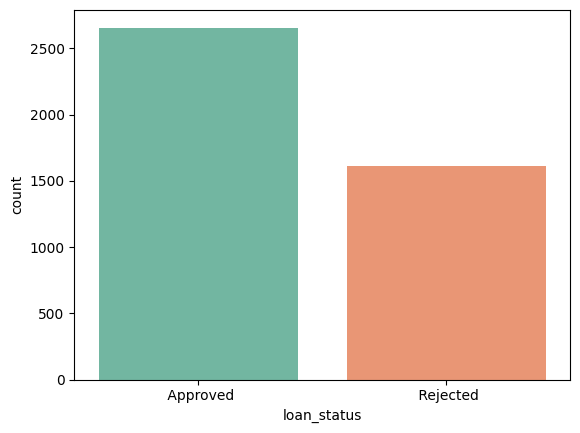

In [9]:
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.show()

### Income Distribution

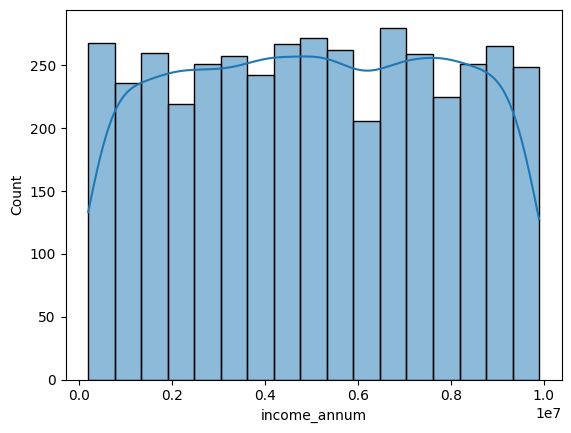

In [10]:
sns.histplot(df['income_annum'], kde=True)
plt.show()

### CIBIL Score vs Loan Status

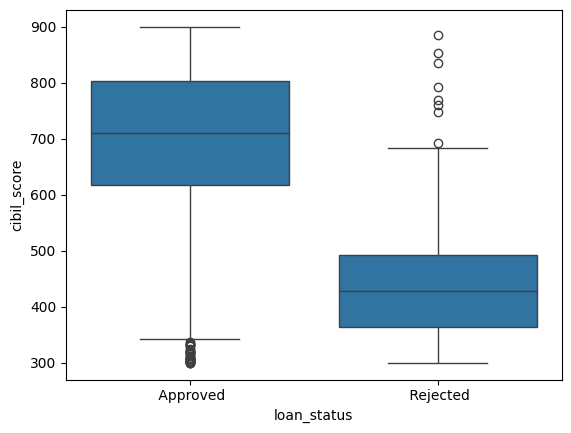

In [11]:
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.show()

### correlation Heatmap

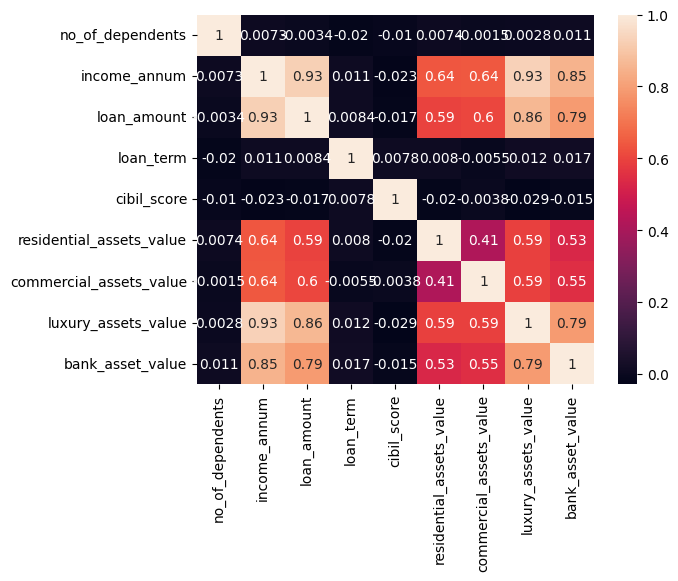

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Step 6. Encoding Categorical Variables

In [13]:
le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

In [14]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## Step 7. Define Feature and Target

In [15]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

## Step 8.train_test-split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9. Model building

### Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(accuracy_score(y_test, lr_pred))

0.7985948477751756


### Decision Tree

In [18]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print(accuracy_score(y_test, dt_pred))

0.977751756440281


### Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(accuracy_score(y_test, rf_pred))

0.977751756440281


## Step 10. Model Evaluation

In [20]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



## Step 11. Confusion Matrix

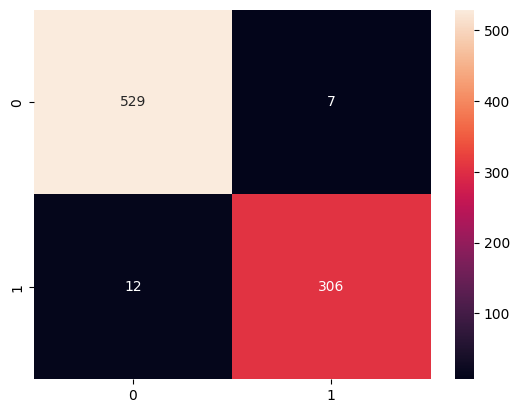

In [21]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Step 12. Feature Importance

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                     Feature  Importance
6                cibil_score    0.809939
5                  loan_term    0.064499
4                loan_amount    0.028938
7   residential_assets_value    0.018168
3               income_annum    0.018060
9        luxury_assets_value    0.017745
10          bank_asset_value    0.015261
8    commercial_assets_value    0.014440
0           no_of_dependents    0.008385
2              self_employed    0.002473
1                  education    0.002093


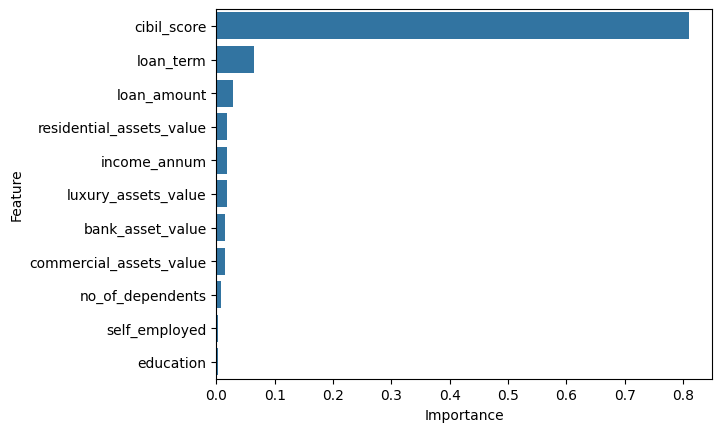

In [23]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.show()

## Step 14. Final Conclusion

In [24]:
print('''
Random Forest gave highest accuracy
CIBIL score most important feature
Higher income applicants had better approval chances
Loan amount also impacted approval decision
''')


Random Forest gave highest accuracy
CIBIL score most important feature
Higher income applicants had better approval chances
Loan amount also impacted approval decision



### Save Model

In [25]:
import pickle

pickle.dump(rf, open("loan_model.pkl", "wb"))

In [26]:
print(rf)

RandomForestClassifier(random_state=42)
